# Insurance Claims: Visual Analysis

Exploratory visual analysis of the **cleaned** synthetic motor claims dataset (14,983 claims), produced after cleaning and feature engineering in `insurance_claims_analysis.ipynb`.

Each chart is followed by a short business insight. All charts are also saved to the `charts/` folder.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df = pd.read_csv("data/insurance_claims_clean.csv", parse_dates=["claim_date", "incident_date"])
os.makedirs("charts", exist_ok=True)
print(df.shape)

(14983, 32)


### Chart style
One consistent, minimal style for every chart: a single blue for single-series charts, light gridlines, no chart junk, and values labelled directly where they help.

In [2]:
BLUE = "#2a78d6"                       # main series colour
RISK_COLOURS = {"Low": "#2a78d6", "Medium": "#eb6834", "High": "#1baf7a"}
TEXT, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlecolor": TEXT, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10,
    "axes.axisbelow": True, "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
})

def hbar(series, title, fmt, xlabel="", ref=None, ref_label=None, filename=None):
    """Sorted horizontal bar chart with direct value labels."""
    s = series.sort_values()
    fig, ax = plt.subplots(figsize=(8, 0.55 * len(s) + 1.2))
    ax.barh(s.index, s.values, color=BLUE, height=0.6)
    ax.grid(axis="y", visible=False)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    for i, v in enumerate(s.values):
        ax.text(v, i, "  " + fmt(v), va="center", color=TEXT, fontsize=9, zorder=5,
                bbox=dict(facecolor="#fcfcfb", edgecolor="none", pad=0.5))
    if ref is not None:
        ax.axvline(ref, color=MUTED, linestyle="--", linewidth=1.2)
        ax.text(ref, -0.75, f" {ref_label}", color=MUTED, fontsize=9, va="center")
        ax.set_ylim(-1, len(s) - 0.4)
    ax.set_xlim(0, s.max() * 1.18)
    if filename:
        fig.savefig(f"charts/{filename}")
    plt.show()

## Chart 1: Claims by month

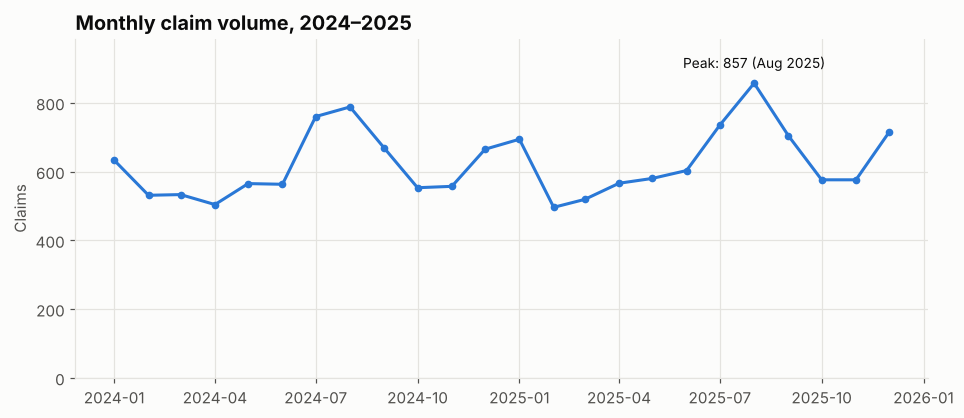

In [3]:
# January 2026 is excluded: it only contains late-reported claims for December 2025
# incidents (an incomplete month), which would show as a misleading drop.
monthly = df[df["claim_date"] < "2026-01-01"].groupby(df["claim_date"].dt.to_period("M")).size()
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly.values, color=BLUE, linewidth=2, marker="o", markersize=4)
ax.set_title("Monthly claim volume, 2024–2025")
ax.set_ylabel("Claims")
ax.set_ylim(0, monthly.max() * 1.15)
peak = monthly.idxmax()
ax.annotate(f"Peak: {monthly.max()} ({peak:%b %Y})", xy=(peak, monthly.max()),
            xytext=(0, 10), textcoords="offset points", ha="center", color=TEXT, fontsize=9)
fig.savefig("charts/01_claims_by_month.png")
plt.show()

**Insight:** Claim volume is clearly seasonal. It rises every **July to September**, with August the busiest month in both years (peak of 857 claims in August 2025), and rises again in December–January. This is consistent with monsoon and winter driving conditions, so claims teams should plan staffing ahead of these peaks.

## Chart 2: Claims by region

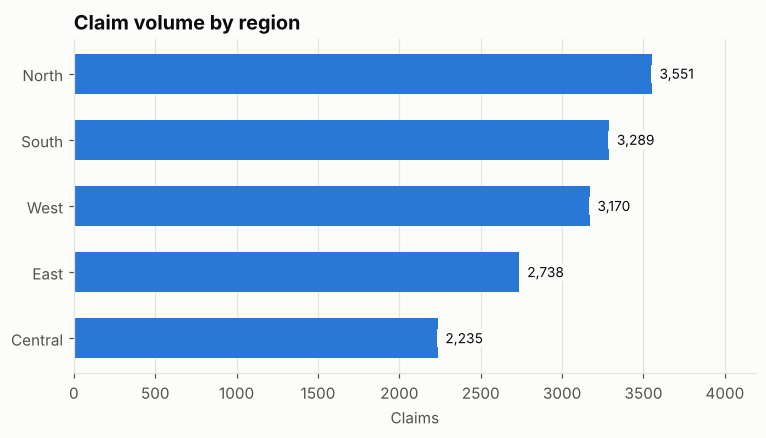

In [4]:
hbar(df["region"].value_counts(), "Claim volume by region", lambda v: f"{v:,.0f}",
     xlabel="Claims", filename="02_claims_by_region.png")

**Insight:** **North** has the highest claim volume (3,551 claims, 24% of the total) and **Central** the lowest (2,235). Volume alone does not show performance, however: Chart 4 and the SQL analysis show that **East**, a mid-volume region, has the worst SLA performance.

## Chart 3: Average claim amount by claim type

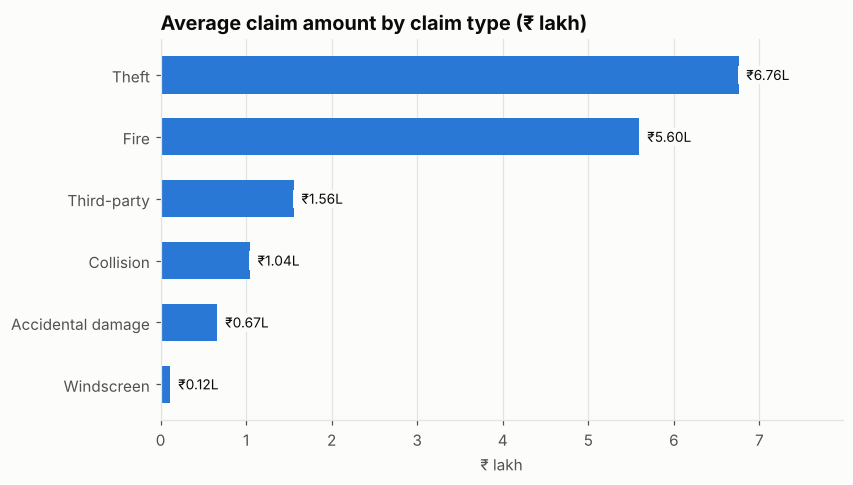

In [5]:
hbar(df.groupby("claim_type")["claim_amount"].mean() / 1e5,
     "Average claim amount by claim type (₹ lakh)", lambda v: f"₹{v:.2f}L",
     xlabel="₹ lakh", filename="03_avg_claim_by_type.png")

**Insight:** **Theft (₹6.76 lakh)** and **fire (₹5.60 lakh)** claims are by far the most expensive, around 58x and 48x the average windscreen claim (₹0.12 lakh). Although they are only ~15% of claim volume, they drive a large share of total claim cost, so they warrant senior handler attention.

## Chart 4: Average processing time by claim type

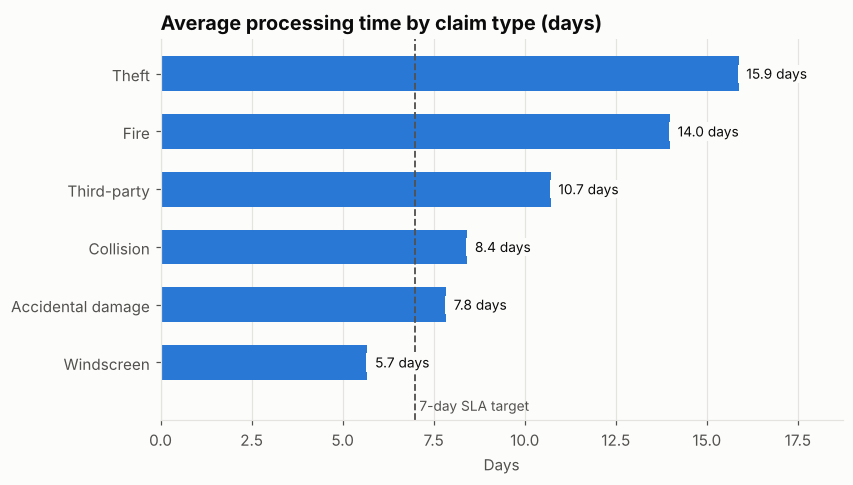

In [6]:
hbar(df.groupby("claim_type")["processing_days"].mean(),
     "Average processing time by claim type (days)", lambda v: f"{v:.1f} days",
     xlabel="Days", ref=7, ref_label="7-day SLA target", filename="04_processing_by_type.png")

**Insight:** Only **windscreen** claims are processed within the 7-day target on average (5.7 days). **Theft (15.9 days)** and **fire (14.0 days)** take more than twice as long. A single 7-day SLA is unrealistic for complex claim types; claim-type-specific targets would give a fairer view of performance (see `sql/04_operational_analysis.sql`, Q2).

## Chart 5: Fraud rate by region

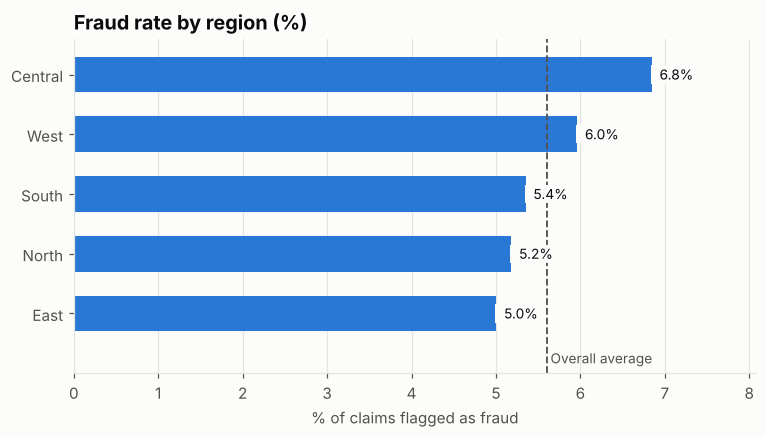

In [7]:
hbar(df.groupby("region")["fraud_flag"].mean() * 100,
     "Fraud rate by region (%)", lambda v: f"{v:.1f}%",
     xlabel="% of claims flagged as fraud", ref=df["fraud_flag"].mean() * 100,
     ref_label="Overall average", filename="05_fraud_by_region.png")

**Insight:** **Central** has the highest fraud rate (6.8%), above the overall average of 5.6%, despite having the lowest claim volume. The differences between regions are modest, so region alone is a weak fraud signal. Claim type and reporting delay (Charts 6 and 9) are much stronger.

## Chart 6: Fraud rate by claim type

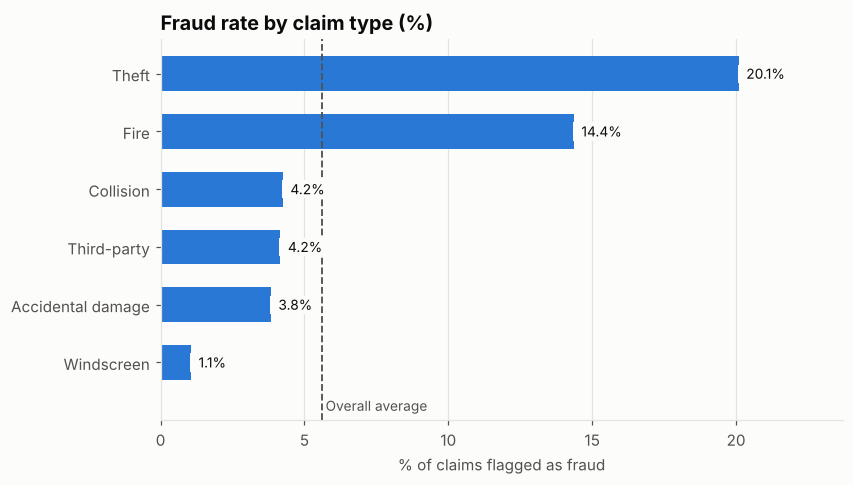

In [8]:
hbar(df.groupby("claim_type")["fraud_flag"].mean() * 100,
     "Fraud rate by claim type (%)", lambda v: f"{v:.1f}%",
     xlabel="% of claims flagged as fraud", ref=df["fraud_flag"].mean() * 100,
     ref_label="Overall average", filename="06_fraud_by_type.png")

**Insight:** **Theft (20.1%)** and **fire (14.4%)** claims have fraud rates several times the overall average, while windscreen claims are rarely fraudulent (1.1%). Combined with Chart 3, this means the highest-value claim types are also the highest-risk ones, which makes them the clearest priority for early investigation.

## Chart 7: Claim amount vs processing days, by risk level

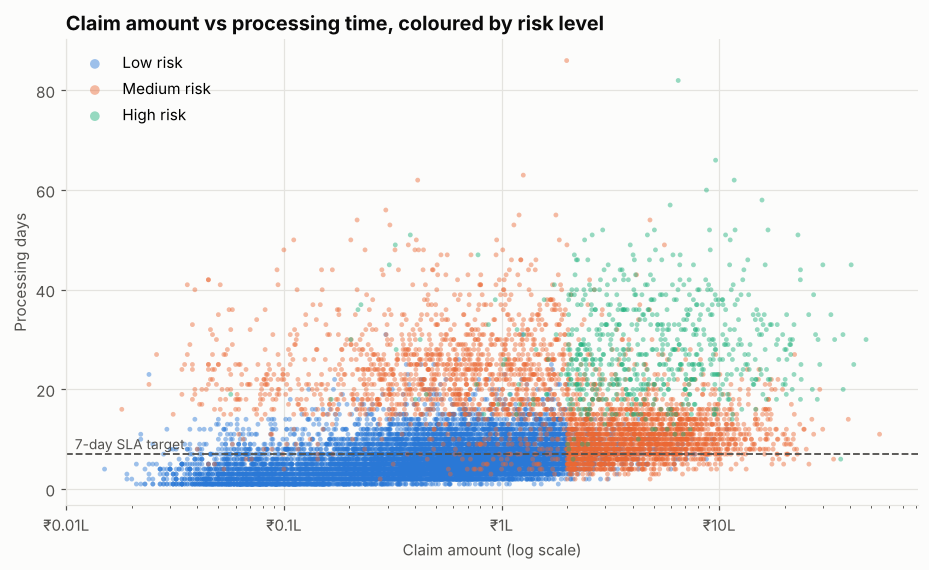

In [9]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for level in ["Low", "Medium", "High"]:
    d = df[df["risk_level"] == level]
    ax.scatter(d["claim_amount"], d["processing_days"], s=10, alpha=0.45,
               color=RISK_COLOURS[level], edgecolors="none", label=f"{level} risk")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"₹{v/1e5:g}L"))
ax.axhline(7, color=MUTED, linestyle="--", linewidth=1.2)
ax.text(ax.get_xlim()[0] * 1.1, 8, "7-day SLA target", color=MUTED, fontsize=9)
ax.set_title("Claim amount vs processing time, coloured by risk level")
ax.set_xlabel("Claim amount (log scale)")
ax.set_ylabel("Processing days")
ax.legend(frameon=False, markerscale=2, loc="upper left")
fig.savefig("charts/07_amount_vs_processing.png")
plt.show()

**Insight:** Most **low-risk** claims cluster below the 7-day line at low and medium values, while **high-risk** claims sit in the upper-right: high value *and* slow to process. Claim amount and processing time are only moderately correlated (r ≈ 0.30), so the slow claims are driven mainly by investigations and missing documents rather than size alone. The sharp colour boundary at ₹2 lakh is the risk score's high-value rule (+2 points) and shows how strongly that single threshold shapes the score; a production model would use smoother scoring.

## Chart 8: Risk score distribution

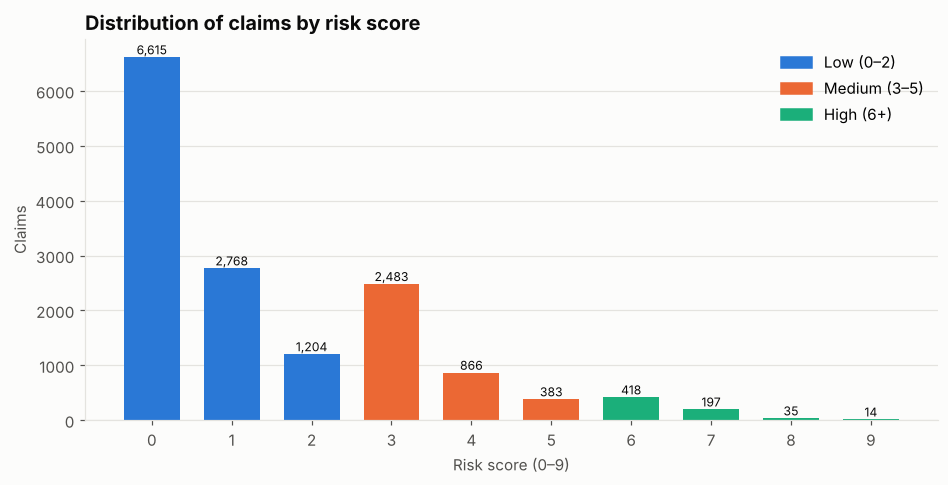

,claims,% of claims,% of value,fraud rate %
risk_level,,,,
High,664,4.4,18.3,55.1
Low,10587,70.7,29.7,1.1
Medium,3732,24.9,52.0,9.5


In [10]:
counts = df["risk_score"].value_counts().sort_index()
level_of = lambda s: "Low" if s <= 2 else ("Medium" if s <= 5 else "High")

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(counts.index, counts.values, width=0.7,
              color=[RISK_COLOURS[level_of(s)] for s in counts.index])
ax.set_xticks(counts.index)
ax.grid(axis="x", visible=False)
ax.set_title("Distribution of claims by risk score")
ax.set_xlabel("Risk score (0–9)")
ax.set_ylabel("Claims")
for x, v in zip(counts.index, counts.values):
    ax.text(x, v, f"{v:,}", ha="center", va="bottom", fontsize=8, color=TEXT)
handles = [plt.Rectangle((0, 0), 1, 1, color=RISK_COLOURS[l]) for l in RISK_COLOURS]
ax.legend(handles, ["Low (0–2)", "Medium (3–5)", "High (6+)"], frameon=False)
fig.savefig("charts/08_risk_distribution.png")
plt.show()

risk = df.groupby("risk_level", observed=True).agg(
    claims=("claim_id", "count"), value=("claim_amount", "sum"), fraud_rate=("fraud_flag", "mean"))
risk["% of claims"] = (100 * risk["claims"] / risk["claims"].sum()).round(1)
risk["% of value"] = (100 * risk["value"] / risk["value"].sum()).round(1)
risk["fraud rate %"] = (100 * risk["fraud_rate"]).round(1)
risk[["claims", "% of claims", "% of value", "fraud rate %"]]

**Insight:** The score is heavily right-skewed: **70.7%** of claims are low risk and only **4.4% (664 claims)** score 6 or more. Those few high-risk claims account for **18.3% of total claim value** and have a **55.1% fraud rate**, compared with 1.1% for low-risk claims. The score concentrates fraud effectively into a small group an investigation team could realistically review.

## Chart 9: Fraud rate by reporting delay

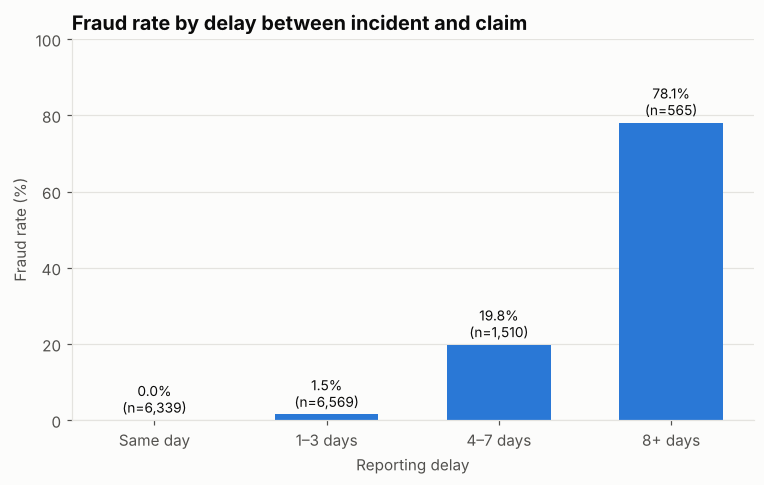

In [11]:
bins = [-1, 0, 3, 7, df["reporting_lag_days"].max()]
labels = ["Same day", "1–3 days", "4–7 days", "8+ days"]
lag = df.assign(delay=pd.cut(df["reporting_lag_days"], bins=bins, labels=labels))
rate = lag.groupby("delay", observed=True)["fraud_flag"].mean() * 100
n = lag["delay"].value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(rate.index.astype(str), rate.values, color=BLUE, width=0.6)
ax.grid(axis="x", visible=False)
ax.set_title("Fraud rate by delay between incident and claim")
ax.set_xlabel("Reporting delay")
ax.set_ylabel("Fraud rate (%)")
ax.set_ylim(0, 100)
for i, (v, c) in enumerate(zip(rate.values, n.values)):
    ax.text(i, v + 2, f"{v:.1f}%\n(n={c:,})", ha="center", fontsize=9, color=TEXT)
fig.savefig("charts/09_fraud_by_reporting_delay.png")
plt.show()

**Insight:** Reporting delay is the **strongest single fraud signal** in the data. Same-day claims show no fraud, but the rate climbs to **19.8%** at 4–7 days and **78.1%** for claims reported 8+ days after the incident. A simple rule flagging late-reported claims for early review would catch a large share of suspicious claims at very low cost.

## Summary of visual findings

1. **Seasonality:** claims peak every July–September, so staffing should be planned ahead.
2. **Cost drivers:** theft and fire claims are the most expensive, the slowest to process, and the most likely to be fraudulent.
3. **SLA:** only windscreen claims meet the 7-day target on average; claim-type-specific targets are more realistic.
4. **Risk score:** 4.4% of claims are high risk but represent 18.3% of claim value and have a 55.1% fraud rate.
5. **Late reporting** is the strongest single fraud indicator (78.1% fraud rate at 8+ days).